# 🏟️ Projeto 5 — O que enche o estádio?
### Machine Learning: **Regressão** (aprendizado supervisionado)

---
### 🎯 Pergunta de pesquisa
> **Quais fatores explicam o tamanho do público** em um jogo da Copa? A capacidade do estádio? A posição na tabela? O valor do elenco? A boa fase do time?

### 📌 Objetivo
Treinar um modelo de **regressão** que preveja **quantos torcedores** vão ao estádio e descobrir quais fatores mais influenciam o público.

---
### 🆕 O que mudou nesta versão
1. **Split cronológico:** treinamos com dados ficticios
2. **Só usamos informações conhecidas ANTES do jogo** — evitamos "vazamento de dados".
3. **Dicionário de features** com descrições em português para o gráfico de importância.

> 💡 **Classificação x Regressão:** no Projeto 1 prevíamos uma *categoria* (quem ganha). Aqui prevemos um *número* (quantas pessoas).

## 1) Importar as bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

print("Bibliotecas carregadas! ✅")

Bibliotecas carregadas! ✅


## 2) Carregar os dados
Cada linha é **um jogo** da Copa, com o público que compareceu.

In [2]:
CAMINHO = "https://raw.githubusercontent.com/paulamacaira/IA-na-Copa---Minicurso-2026/main/dados/publico_copa.csv"
df = pd.read_csv(CAMINHO)
print("A tabela tem", df.shape[0], "jogos.")
print("Anos disponíveis:", sorted(df["ano_campeonato"].unique()))
df.head()

A tabela tem 455 jogos.
Anos disponíveis: [np.int64(2017), np.int64(2018), np.int64(2019)]


,ano_campeonato,rodada,estadio,publico,publico_max,publico_medio_mandante,colocacao_mandante,colocacao_visitante,time_mandante,time_visitante,...,valor_equipe_titular_visitante,resultado_mandante,resultado_ultimo_jogo_mandante,saldo_gols_ultimo_jogo_mandante,sequencia_vitoria_mandante,sequencia_derrota_mandante,resultado_ultimo_jogo_visitante,saldo_gols_ultimo_jogo_visitante,sequencia_vitoria_visitante,sequencia_derrota_visitante
0,2017,1,Mercedes-Benz Stadium,33425,43600.0,33425.0,2,19,Costa do Marfim,Irã,...,8530000.0,1,0,0,1,0,0,0,1,0
1,2017,1,NRG Stadium,8127,55000.0,8127.0,1,18,Iraque,Japão,...,15400000.0,1,0,0,1,0,0,0,1,0
2,2017,2,Gillette Stadium,10323,22600.0,10323.0,11,2,Espanha,Jordânia,...,21500000.0,1,0,0,2,0,1,4,2,0
3,2017,2,NRG Stadium,16515,55000.0,16515.0,13,8,Bósnia e Herzegovina,Coreia do Sul,...,21750000.0,-1,0,0,2,0,0,0,2,0
4,2017,2,AT&T Stadium,17244,42372.0,17244.0,18,5,Inglaterra,Portugal,...,28300000.0,-1,-1,-4,0,1,1,2,2,0


Jogos com torcida: 454


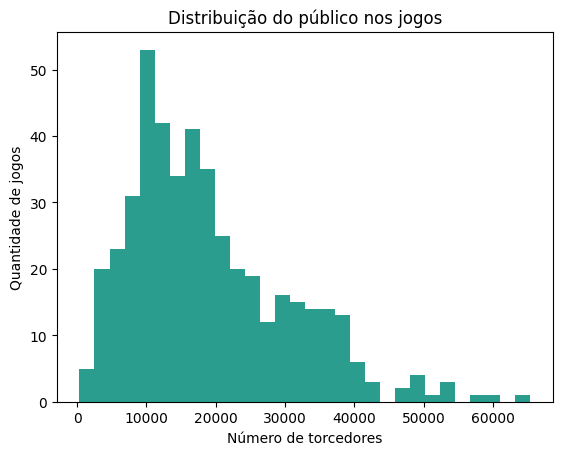

In [3]:
# Alguns jogos de 2020/2021 tiveram portões fechados (pandemia): público = 0.
# Aqui os dados vão até 2019, mas garantimos que só estudamos jogos COM torcida.
df = df[df["publico"] > 0].copy()
print("Jogos com torcida:", df.shape[0])

plt.hist(df["publico"], bins=30, color="#2a9d8f")
plt.title("Distribuição do público nos jogos")
plt.xlabel("Número de torcedores")
plt.ylabel("Quantidade de jogos")
plt.show()

## 3) Escolher as pistas e **descrever cada uma**
> ⚠️ **Evitando vazamento de dados:** só podemos usar o que é conhecido **antes** do jogo. Por isso **NÃO** usamos `gols_mandante`, `resultado_mandante` (só sabemos no fim) nem `publico_medio_mandante` (é calculado a partir do próprio público — seria "colar"!).

In [ ]:
# Dicionário: nome_da_coluna -> descrição em português
DESCRICOES = {
    "publico_max":                     "Capacidade do estádio",
    "rodada":                          "Rodada do campeonato (1 a 38)",
    "colocacao_mandante":              "Posição do mandante na tabela",
    "colocacao_visitante":             "Posição do visitante na tabela",
    "valor_equipe_titular_mandante":   "Valor do elenco titular (mandante)",
    "valor_equipe_titular_visitante":  "Valor do elenco titular (visitante)",
    "sequencia_vitoria_mandante":      "Vitórias seguidas (mandante)",
    "sequencia_derrota_mandante":      "Derrotas seguidas (mandante)",
    "sequencia_vitoria_visitante":     "Vitórias seguidas (visitante)",
    "sequencia_derrota_visitante":     "Derrotas seguidas (visitante)",
    "saldo_gols_ultimo_jogo_mandante": "Saldo de gols no último jogo (mandante)",
    "saldo_gols_ultimo_jogo_visitante":"Saldo de gols no último jogo (visitante)",
}

pistas = list(DESCRICOES.keys())

dados = df.dropna(subset=pistas + ["publico"]).copy()
print("Jogos usados:", dados.shape[0])

X = dados[pistas]
y = dados["publico"]

Jogos usados: 440


## 4) Separar treino e teste **pelo tempo** (split cronológico) 📅
Treino = **2017 e 2018**. Teste = **2019**.

> 🧠 **Repare:** usamos `ano_campeonato` apenas para **dividir** treino/teste, e **não** como pista. Se usássemos o ano como feature, o modelo veria no teste um ano (2019) que nunca apareceu no treino — e árvores não sabem "extrapolar" para valores novos. Ótimo assunto para discutir em aula!

In [ ]:
eh_teste = dados["ano_campeonato"] == 2019

X_treino, y_treino = X[~eh_teste], y[~eh_teste]   # 2017 + 2018
X_teste,  y_teste  = X[eh_teste],  y[eh_teste]    # 2019

print("Treino (2017-2018):", X_treino.shape[0], "jogos")
print("Teste  (2019)     :", X_teste.shape[0], "jogos")

Treino (2017-2018): 287 jogos
Teste  (2019)     : 153 jogos


## 5) Modelo 0 — Baseline
Um modelo bobo que sempre "chuta" o público médio do treino. Nosso modelo precisa ser melhor que isso.

In [ ]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_treino, y_treino)
prev_base = baseline.predict(X_teste)
print(f"Baseline — erro médio: {mean_absolute_error(y_teste, prev_base):,.0f} torcedores")

Baseline — erro médio: 9,819 torcedores


## 6) Treinar o modelo de regressão 🌳

In [ ]:
modelo = RandomForestRegressor(n_estimators=200, random_state=42)
modelo.fit(X_treino, y_treino)

previsoes = modelo.predict(X_teste)
erro = mean_absolute_error(y_teste, previsoes)
r2 = r2_score(y_teste, previsoes)
print(f"Random Forest — erro médio: cerca de {erro:,.0f} torcedores por jogo.")
print(f"O modelo explica {r2*100:.0f}% da variação do público (R²).")
print(f"(Baseline errava {mean_absolute_error(y_teste, prev_base):,.0f} torcedores.)")

Random Forest — erro médio: cerca de 6,352 torcedores por jogo.
O modelo explica 54% da variação do público (R²).
(Baseline errava 9,819 torcedores.)


### Previsto x Real
Se o modelo fosse perfeito, os pontos ficariam sobre a linha vermelha.

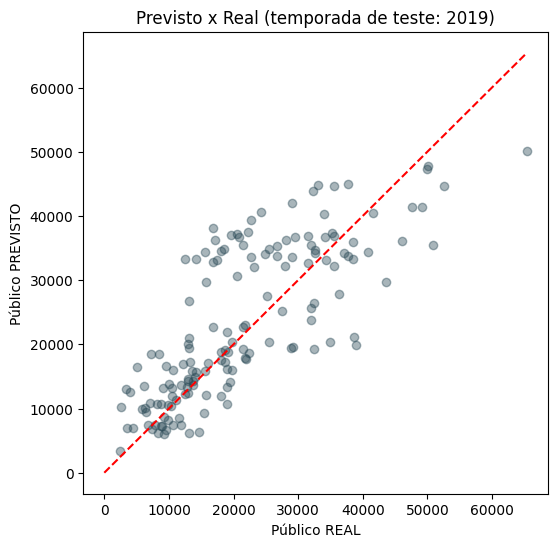

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_teste, previsoes, alpha=0.4, color="#264653")
lim = [0, max(y_teste.max(), previsoes.max())]
plt.plot(lim, lim, "r--")
plt.xlabel("Público REAL")
plt.ylabel("Público PREVISTO")
plt.title("Previsto x Real (temporada de teste: 2019)")
plt.show()

## 7) Quais fatores mais enchem o estádio? (com descrições)

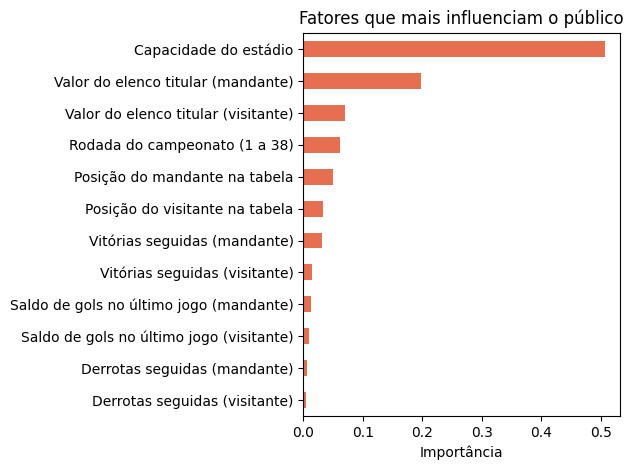

Fator mais importante: Capacidade do estádio


In [ ]:
importancias = (pd.Series(modelo.feature_importances_, index=pistas)
                  .rename(DESCRICOES)
                  .sort_values())

importancias.plot(kind="barh", color="#e76f51")
plt.title("Fatores que mais influenciam o público")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

print("Fator mais importante:", importancias.idxmax())

## 🧪 Experimente você mesmo!
1. **Tire a capacidade do estádio:** remova `"publico_max"` de `DESCRICOES` e rode de novo. O erro aumenta muito?
2. **Só desempenho:** monte `DESCRICOES` só com posição e sequências de vitória. Time em boa fase atrai mais torcida?
3. **Valor do time:** compare a importância de `valor_equipe_titular_mandante`. Time mais caro leva mais gente?
4. **Desafio:** troque o modelo por `from sklearn.linear_model import LinearRegression` e use `LinearRegression()`. Fica melhor ou pior?

✍️ **Sua conclusão:**
> ...